In [1]:
# Installing required libraries 
!pip install kaggle tensorflow scikit-learn scikit-image matplotlib seaborn joblib pillow

In [2]:
# Standard Library
import os
import zipfile
import json
import warnings
warnings.filterwarnings("ignore")

# Data Handling 
# NumPy and Pandas are used for numerical operations
# and organizing data into tables/dataframes
import numpy as np
import pandas as pd

# Visualization 
# Matplotlib and Seaborn are used to create graphs,
# plots, and dataset visualizations
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Image Processing
# PIL and scikit-image are used for loading, processing,
# and extracting features from images
from PIL import Image
from skimage.feature import hog
from skimage.color import rgb2gray
from skimage import exposure

# Classical ML
# Scikit-learn provides machine learning algorithms,
# preprocessing tools, and evaluation metrics
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Saving Models
import joblib

print("All libraries imported successfully")
print(f"   TensorFlow version : {tf.__version__}")
print(f"   GPU available      : {bool(tf.config.list_physical_devices('GPU'))}")

2026-05-22 10:24:41.827897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779445482.315497      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779445482.429358      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779445483.461564      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779445483.461699      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779445483.461702      57 computation_placer.cc:177] computation placer alr

All libraries imported successfully
   TensorFlow version : 2.19.0
   GPU available      : True


In [3]:
# Dataset Path 
IMAGE_ROOT = '/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color'

# Verifying that path exists and show basic info
if os.path.exists(IMAGE_ROOT):
    classes    = sorted(os.listdir(IMAGE_ROOT))
    n_classes  = len(classes)
    total_imgs = sum(
        len(os.listdir(os.path.join(IMAGE_ROOT, c)))
        for c in classes
    )
    print(f"Dataset found at: {IMAGE_ROOT}")
    print(f"   Classes : {n_classes}")
    print(f"   Images  : {total_imgs:,}")
else:
    print("Path not found")


Dataset found at: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
   Classes : 38
   Images  : 54,305


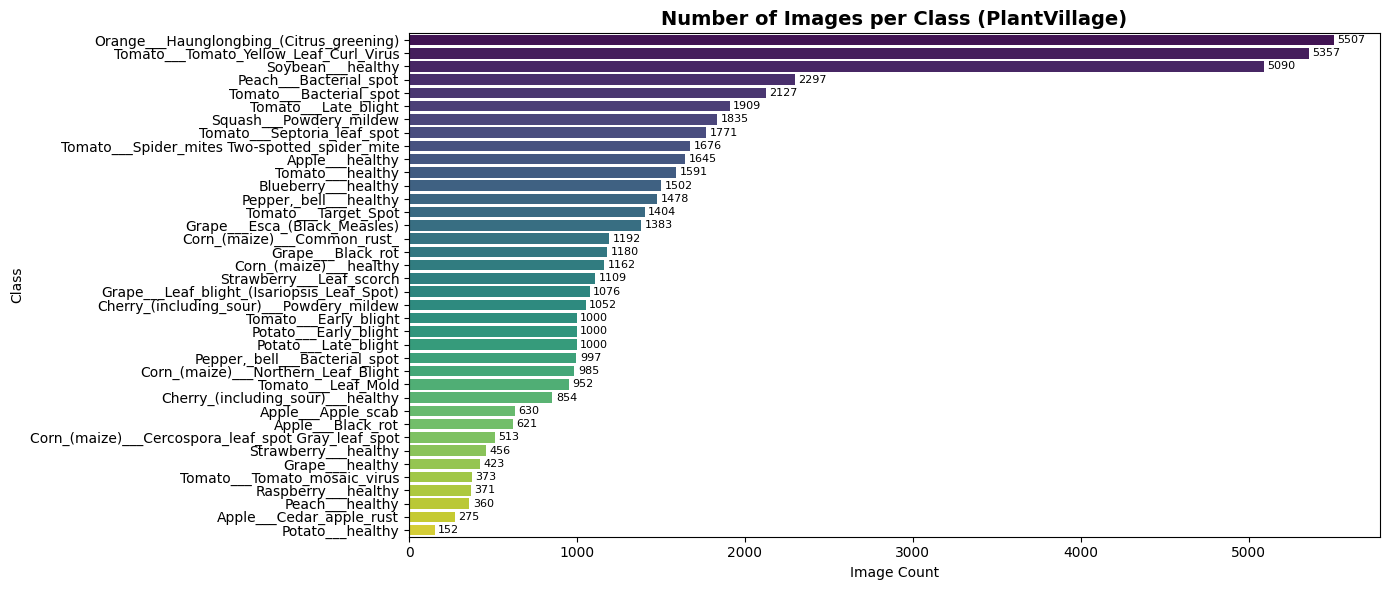

Saved -> class_distribution.png


In [4]:
# Count images per class and visualize to check for imbalance, this helps dataset distribution
class_counts = {
    c: len(os.listdir(os.path.join(IMAGE_ROOT, c)))
    for c in classes
}
counts_series = pd.Series(class_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=counts_series.values, y=counts_series.index,
            palette="viridis", ax=ax)
ax.set_title("Number of Images per Class (PlantVillage)", fontsize=14, fontweight="bold")
ax.set_xlabel("Image Count")
ax.set_ylabel("Class")
for i, v in enumerate(counts_series.values):
    ax.text(v + 20, i, str(v), va="center", fontsize=8)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved -> class_distribution.png")

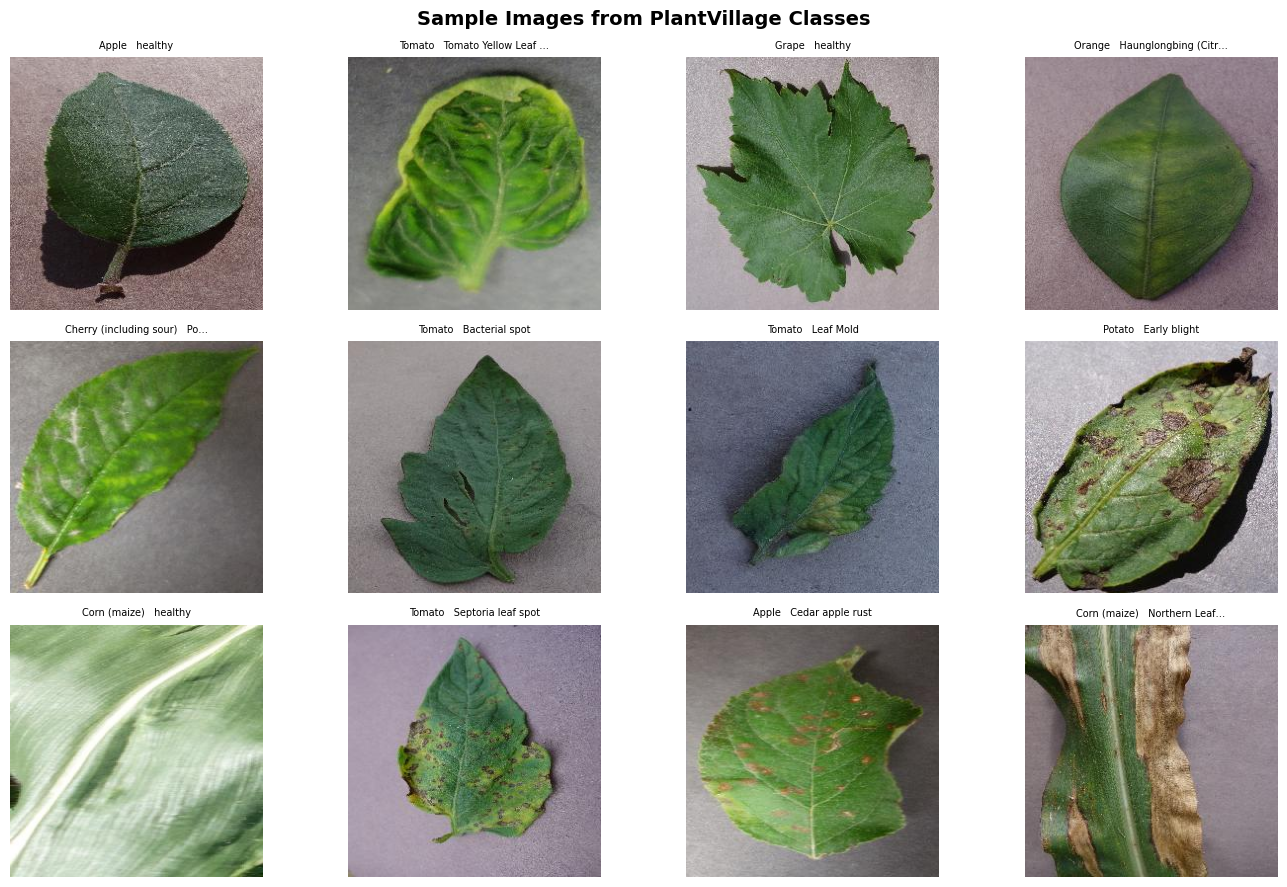

Saved -> sample_images.png


In [5]:
# Show one sample image from 12 randomly chosen classes
sample_classes = np.random.choice(classes, size=12, replace=False)

# Creating a 3x4 grid for image visualization
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.flatten()

for ax, cls in zip(axes, sample_classes):
    folder   = os.path.join(IMAGE_ROOT, cls)
    img_file = os.path.join(folder, os.listdir(folder)[0])
    img = mpimg.imread(img_file)
    ax.imshow(img)

# Replace underscores with spaces, shorten very long labels if necessary

    label = cls.replace("_", " ")
    label = label if len(label) < 30 else label[:28] + "…"
    ax.set_title(label, fontsize=7)
    ax.axis("off")

fig.suptitle("Sample Images from PlantVillage Classes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()
print("Saved -> sample_images.png")

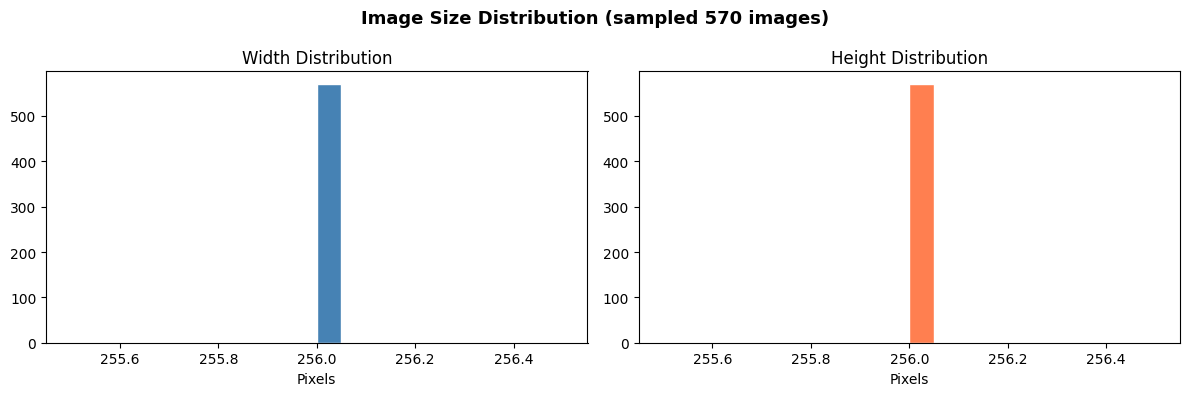

Width  — min: 256  max: 256  mean: 256
Height — min: 256 max: 256 mean: 256


In [6]:
# Sample images to check if sizes are consistent across the dataset
widths, heights = [], []

for cls in classes:
    folder = os.path.join(IMAGE_ROOT, cls)
    for fname in os.listdir(folder)[:15]:      # 15 per class
        fpath = os.path.join(folder, fname)
        try:
            # Open the image and extract width and height
            with Image.open(fpath) as img:
                w, h = img.size
                widths.append(w)
                heights.append(h)
                
        # Skipping corrupted or unreadable files if any exist
        except Exception:
            pass

# Create histograms to visualize the distribution
# of image widths and heights in the dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Width Distribution");  axes[0].set_xlabel("Pixels")
axes[1].hist(heights, bins=20, color="coral",     edgecolor="white")
axes[1].set_title("Height Distribution"); axes[1].set_xlabel("Pixels")

fig.suptitle(f"Image Size Distribution (sampled {len(widths)} images)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("size_distribution.png", dpi=150)
plt.show()

print(f"Width  — min: {min(widths)}  max: {max(widths)}  mean: {np.mean(widths):.0f}")
print(f"Height — min: {min(heights)} max: {max(heights)} mean: {np.mean(heights):.0f}")

In [7]:
# All tunable constants in one place 

IMG_SIZE    = 224        # EfficientNetB0 native input size
BATCH_SIZE  = 32
EPOCHS_HEAD = 10         # Phase 1: train head only, backbone frozen
EPOCHS_FINE = 15         # Phase 2: fine-tune top backbone layers
LR_HEAD     = 1e-3
LR_FINE     = 1e-5       # Much lower LR to avoid destroying pretrained weights

# Classical ML settings
HOG_SIZE    = 64         # resize images before HOG extraction
HOG_SAMPLES = 200        # images per class (keeps RAM manageable)

SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Config set")
print(f"   Deep learning image size : {IMG_SIZE}×{IMG_SIZE}")
print(f"   Classical ML image size  : {HOG_SIZE}×{HOG_SIZE}")
print(f"   Classes                  : {n_classes}")

Config set
   Deep learning image size : 224×224
   Classical ML image size  : 64×64
   Classes                  : 38


In [8]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# EfficientNetB0 has its own preprocessing 
# It expects pixel values in [0, 255] range and handles normalization internally

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # correct EfficientNet preprocessing
    validation_split=0.2,     # Reserve 20% of data for validation
    # Data augmentation techniques
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Validation Data Generator 
# Validation data is only preprocessed without augmentation to evaluate the model on unchanged images

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    IMAGE_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    seed=SEED
)

# Training Generator, load training images directly from dataset folders

val_gen = val_datagen.flow_from_directory(
    IMAGE_ROOT,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    seed=SEED,
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
joblib.dump(CLASS_NAMES, "class_names.pkl")

print(f"Generators ready")
print(f"   Train : {train_gen.samples:,} images")
print(f"   Val   : {val_gen.samples:,} images")

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Generators ready
   Train : 43,456 images
   Val   : 10,849 images


In [12]:
# Build EfficientNetB0 Model, This function creates a deep learning model using
# transfer learning with EfficientNetB0.
# Transfer learning allows us to use a pretrained model
# (trained on ImageNet) and adapt it for plant disease
# classification with fewer training resources.
def build_efficientnet(n_classes, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Transfer learning with EfficientNetB0.
    Phase 1 — freeze backbone, train new head only.
    Phase 2 — unfreeze top layers and fine-tune with tiny LR.
    """
    # Load EfficientNetB0 without the original classification layer
    # include_top=False removes ImageNet output layers
    backbone = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = False

    inputs  = tf.keras.Input(shape=input_shape)
    x       = backbone(inputs)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation="relu")(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="PlantDisease_EfficientNetB0")
    return model, backbone

model_dl, backbone = build_efficientnet(n_classes)
model_dl.summary(line_length=80)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "PlantDisease_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)       │ (None, 7, 7, 1280)       │     4,049,571 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ global_average_pooling2d          │ (None, 1280)             │             0 │
│ (GlobalAveragePooling2D)          │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 1280)             │         5,120 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 38)               │         9,766 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 4,392,393 (16.76 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
# Compile the Model 
model_dl.compile(
    optimizer=Adam(LR_HEAD),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_head = [
    # Stop training early if validation accuracy does not improve for several epochs
    
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),

    # Reduce learning rate automatically when validation loss stops improving
    
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),

    # Save the best-performing model during training

    ModelCheckpoint("best_head.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=0)
]

print("Phase 1 — Training classification head (backbone frozen) …")
history_head = model_dl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks_head,
    verbose=1
)

Phase 1 — Training classification head (backbone frozen) …
Epoch 1/10


I0000 00:00:1779446457.352639     175 service.cc:152] XLA service 0x7cda00002db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779446457.352679     175 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779446457.352683     175 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779446459.933597     175 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-22 10:41:08.953004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 10:41:09.096461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 10:41:09.443756: E external/local_xl

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.7776 - loss: 0.8099

2026-05-22 10:56:48.415248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 10:56:48.550696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 10:56:49.288089: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-22 10:56:49.422980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 968s 690ms/step - accuracy: 0.7776 - loss: 0.8097 - val_accuracy: 0.9352 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 673s 495ms/step - accuracy: 0.9202 - loss: 0.2514 - val_accuracy: 0.9511 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 562s 414ms/step - accuracy: 0.9323 - loss: 0.2115 - val_accuracy: 0.9541 - val_loss: 0.1473 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 549s 404ms/step - accuracy: 0.9388 - loss: 0.1921 - val_accuracy: 0.9612 - val_loss: 0.1203 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 553s 407ms/step - accuracy: 0.9422 - loss: 0.1781 - val_accuracy: 0.9673 - val_loss: 0.1033 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 546s 402ms/step - accuracy: 0.9456 - loss: 0.1719 - val_accuracy: 0.9657 - val_loss: 0.1092 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accur

In [14]:
# Unfreeze top 30 layers of backbone for domain adaptation
# Lower layers (generic edges/textures) stay frozen
backbone.trainable = True

# We keep most lower layers frozen because they learn
# general image features such as edges and textures.
# Only the top 30 layers are unfrozen so the model
# can learn more domain-specific plant features.

for layer in backbone.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in model_dl.layers if l.trainable)
print(f"   Trainable layers after unfreezing: {trainable_count}")

model_dl.compile(
    optimizer=Adam(LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_fine = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1),
    ModelCheckpoint("best_model.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=0)
]

print("Phase 2 — Fine-tuning top backbone layers …")
history_fine = model_dl.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINE,
    callbacks=callbacks_fine,
    verbose=1
)

   Trainable layers after unfreezing: 7
Phase 2 — Fine-tuning top backbone layers …
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 591s 414ms/step - accuracy: 0.8777 - loss: 0.4207 - val_accuracy: 0.9556 - val_loss: 0.1438 - learning_rate: 1.0000e-05
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 557s 410ms/step - accuracy: 0.9350 - loss: 0.2065 - val_accuracy: 0.9665 - val_loss: 0.1108 - learning_rate: 1.0000e-05
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 568s 418ms/step - accuracy: 0.9516 - loss: 0.1502 - val_accuracy: 0.9712 - val_loss: 0.0972 - learning_rate: 1.0000e-05
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 584s 429ms/step - accuracy: 0.9572 - loss: 0.1342 - val_accuracy: 0.9733 - val_loss: 0.0882 - learning_rate: 1.0000e-05
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 542s 399ms/step - accuracy: 0.9622 - loss: 0.1160 - val_accuracy: 0.9759 - val_loss: 0.0807 - learning_rate: 1.0000e-05
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 579s 427ms/step - accuracy: 0.9660 - loss: 0.1028 - val_accuracy

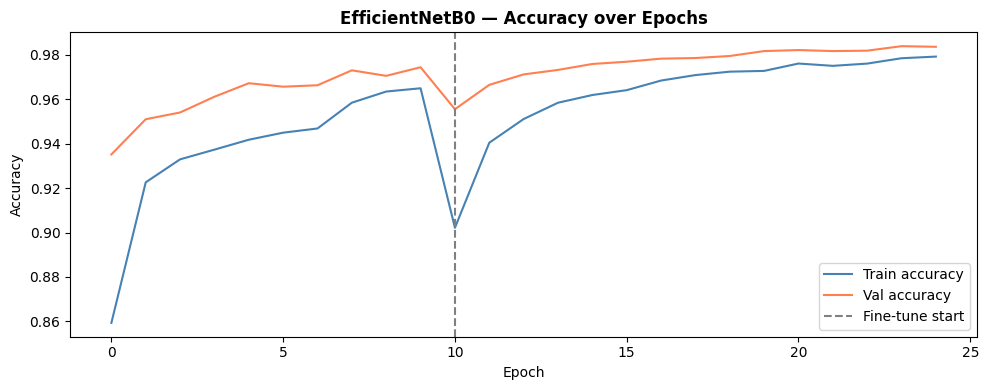

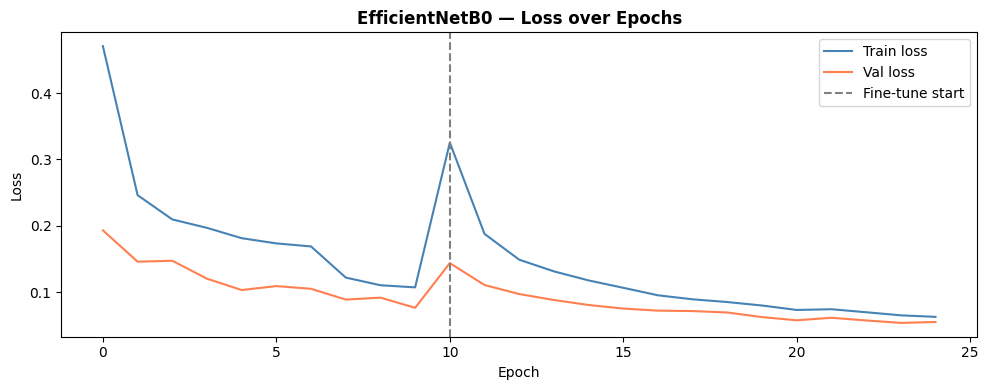

Saved training curves


In [15]:
# Training History Visualization 

def plot_history(h1, h2, metric="accuracy"):
    v1  = h1.history[metric];        v2  = h2.history[metric]
    vv1 = h1.history[f"val_{metric}"]; vv2 = h2.history[f"val_{metric}"]
    all_train = v1 + v2;  all_val = vv1 + vv2
    split_pt  = len(v1)

    plt.figure(figsize=(10, 4))
    plt.plot(all_train, label=f"Train {metric}", color="steelblue")
    plt.plot(all_val,   label=f"Val {metric}",   color="coral")
    plt.axvline(split_pt, linestyle="--", color="gray", label="Fine-tune start")
    plt.title(f"EfficientNetB0 — {metric.capitalize()} over Epochs", fontweight="bold")
    plt.xlabel("Epoch"); plt.ylabel(metric.capitalize())
    plt.legend(); plt.tight_layout()
    plt.savefig(f"dl_{metric}_curve.png", dpi=150)
    plt.show()

plot_history(history_head, history_fine, "accuracy")
plot_history(history_head, history_fine, "loss")
print("Saved training curves")

In [16]:
# Load Best Fine-Tuned Model 
# Load the saved model that achieved the best validation performance
# during training (from ModelCheckpoint)
model_dl = tf.keras.models.load_model("best_model.keras")

# Generate Predictions on Validation Set 
# Reset generator to ensure predictions align correctly with labels

val_gen.reset()
dl_preds_prob = model_dl.predict(val_gen, verbose=1)
dl_preds      = np.argmax(dl_preds_prob, axis=1)
dl_true       = val_gen.classes

# Evaluate Model Performance 
# Compute overall validation accuracy

dl_accuracy = accuracy_score(dl_true, dl_preds)
print(f"\n EfficientNetB0 — Validation Accuracy: {dl_accuracy:.4f}")
print(classification_report(dl_true, dl_preds,
                             target_names=CLASS_NAMES, zero_division=0))

joblib.dump(round(dl_accuracy, 4), "dl_accuracy.pkl")

340/340 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step

 EfficientNetB0 — Validation Accuracy: 0.9840
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.95      0.98       126
                                 Apple___Black_rot       0.99      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       0.99      0.99      0.99       329
                               Blueberry___healthy       0.99      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       0.99      0.99      0.99       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.90      0.82      0.86       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.0

['dl_accuracy.pkl']

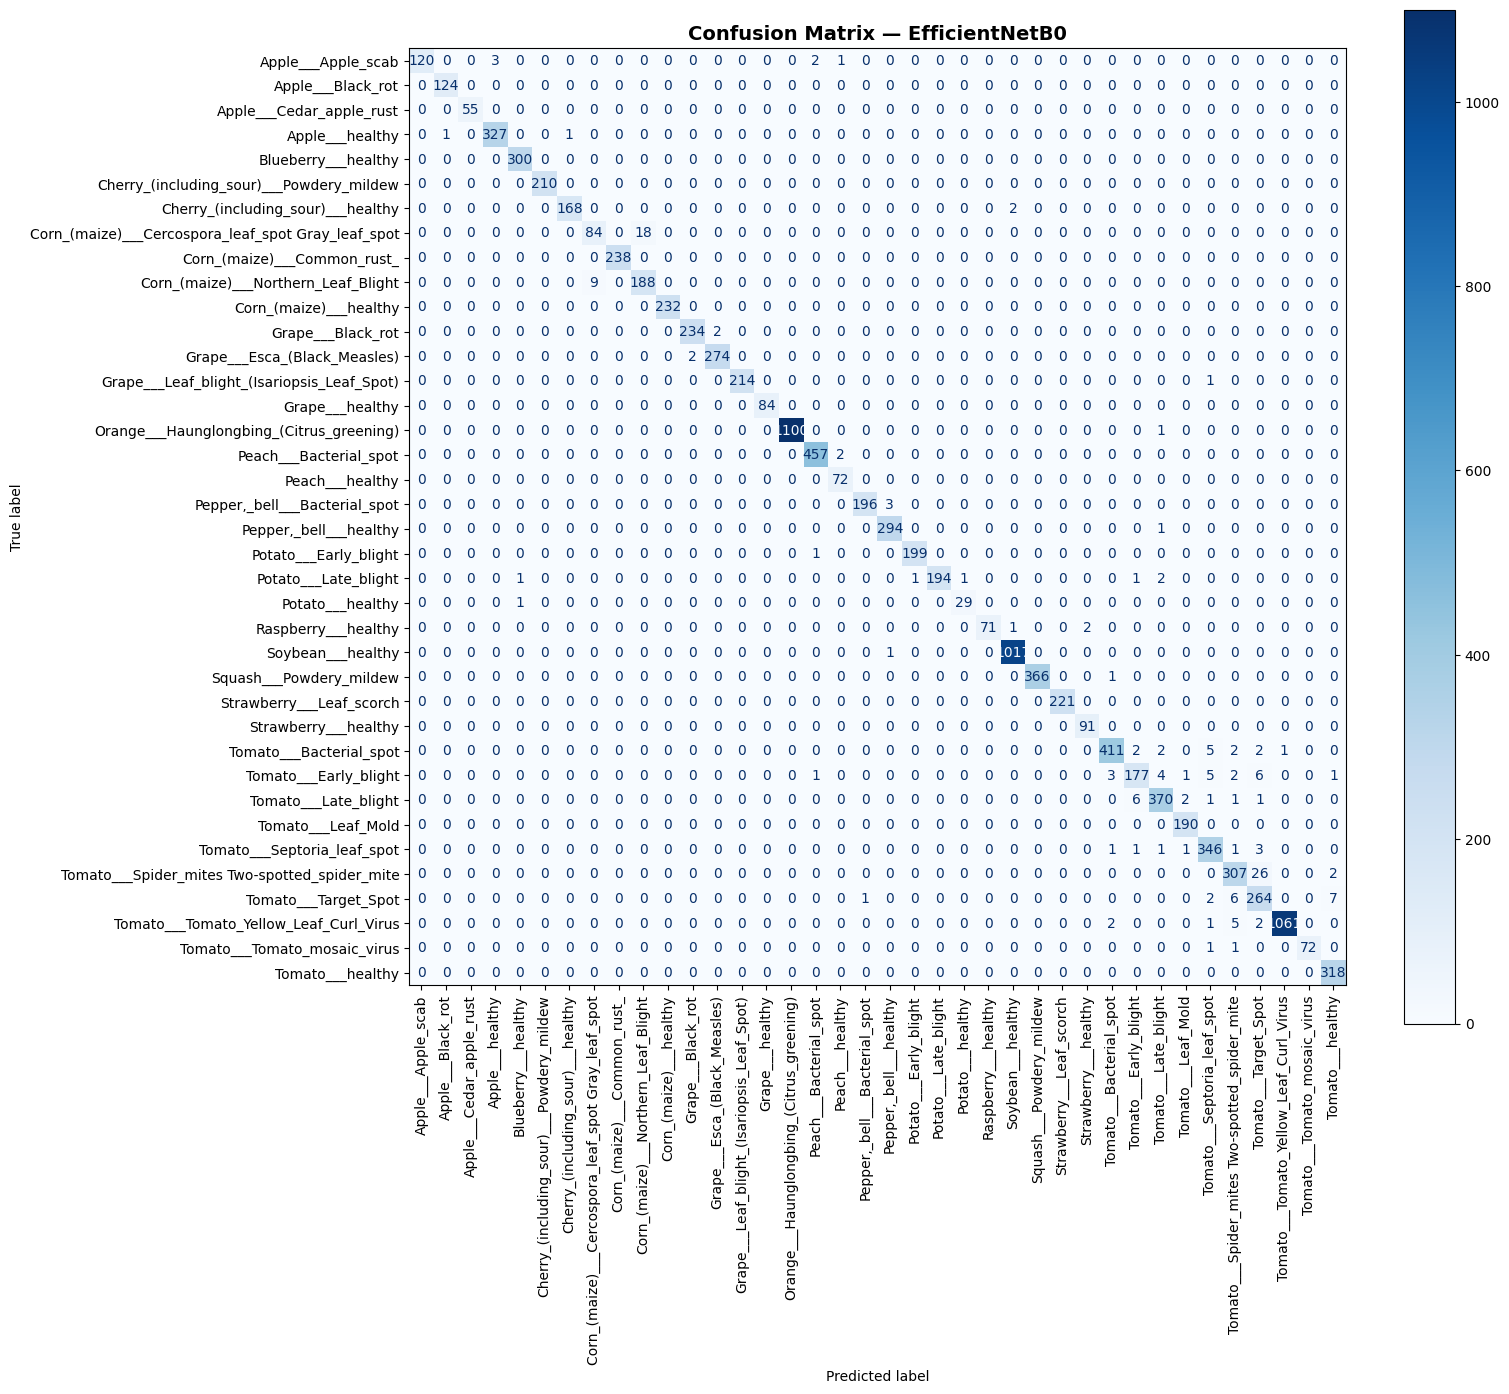

Saved -> cm_efficientnet.png


In [17]:
# Confusion Matrix 
# The confusion matrix shows how well the model performs
# on each class by comparing:
# - True labels (actual classes)
# - Predicted labels (model outputs)
# This helps in identify which plant diseases are
# being confused with others.
cm_dl = confusion_matrix(dl_true, dl_preds)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(cm_dl, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=True, xticks_rotation=90,
          cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix — EfficientNetB0", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("cm_efficientnet.png", dpi=150)
plt.show()
print("Saved -> cm_efficientnet.png")

In [18]:
# HOG Feature Extraction 
# This section extracts handcrafted features using HOG (Histogram of Oriented Gradients).

# HOG is a classical computer vision technique that:
# - Converts images into grayscale
# - Captures edge/shape information
# - Represents images as feature vectors instead of raw pixels

def extract_hog_features(img_path, size=HOG_SIZE):
    """Resize -> grayscale -> HOG feature vector."""
    img  = Image.open(img_path).convert("RGB").resize((size, size))
    gray = rgb2gray(np.array(img))
    feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys"
    )
    return feat

print(f"Extracting HOG features ({HOG_SAMPLES} images/class) …")
X_hog, y_hog = [], []

for cls in classes:
    folder = os.path.join(IMAGE_ROOT, cls)
    files  = os.listdir(folder)[:HOG_SAMPLES]
    for fname in files:
        fpath = os.path.join(folder, fname)
        try:
            feat = extract_hog_features(fpath)
            X_hog.append(feat)
            y_hog.append(cls)
        except Exception:
            pass

X_hog = np.array(X_hog)
y_hog = np.array(y_hog)
print(f"HOG dataset shape : {X_hog.shape}")
print(f"   Labels shape      : {y_hog.shape}")

Extracting HOG features (200 images/class) …
HOG dataset shape : (7552, 1764)
   Labels shape      : (7552,)


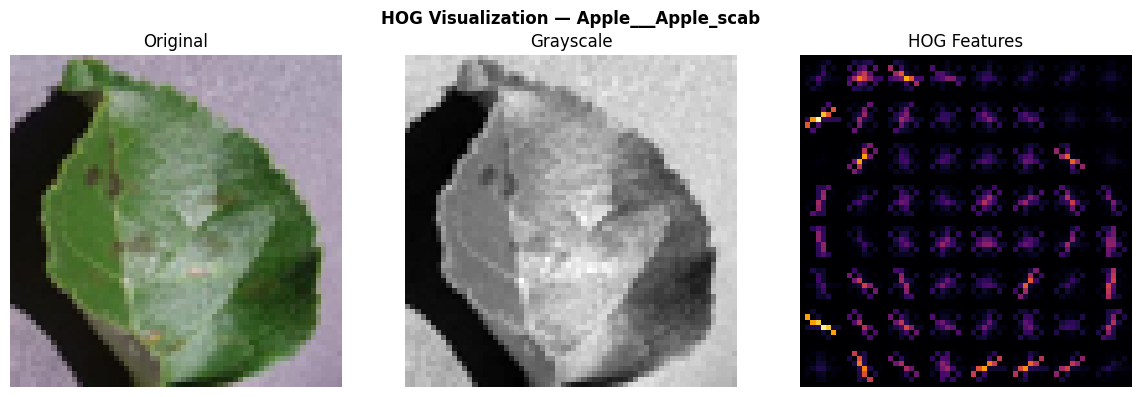

In [19]:
# HOG Visualization Example 
# This section visually demonstrates how HOG (Histogram of Oriented Gradients)
# transforms an image into a feature representation.
sample_cls  = classes[0]
sample_file = os.path.join(IMAGE_ROOT, sample_cls,
                           os.listdir(os.path.join(IMAGE_ROOT, sample_cls))[0])

img_orig = Image.open(sample_file).convert("RGB").resize((HOG_SIZE, HOG_SIZE))
gray_img = rgb2gray(np.array(img_orig))

feat_vis, hog_img = hog(
    gray_img, orientations=9, pixels_per_cell=(8, 8),
    cells_per_block=(2, 2), block_norm="L2-Hys", visualize=True
)
# Improve visibility of HOG output
hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_orig);                axes[0].set_title("Original");    axes[0].axis("off")
axes[1].imshow(gray_img, cmap="gray");   axes[1].set_title("Grayscale");   axes[1].axis("off")
axes[2].imshow(hog_img_rescaled, cmap="inferno"); axes[2].set_title("HOG Features"); axes[2].axis("off")
fig.suptitle(f"HOG Visualization — {sample_cls}", fontweight="bold")
plt.tight_layout()
plt.savefig("hog_example.png", dpi=150)
plt.show()

In [20]:
# Label Encoding 
# Convert string class labels (plant disease names)
# into numerical values that machine learning models can understand
le = LabelEncoder()
y_encoded = le.fit_transform(y_hog)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hog)

# PCA reduces HOG dimensions while keeping 95% of variance
# This speeds up SVM training significantly
pca = PCA(n_components=0.95, random_state=SEED, svd_solver="full")
X_pca = pca.fit_transform(X_scaled)
print(f"   HOG dims after PCA : {X_pca.shape[1]}  (from {X_hog.shape[1]})")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_pca, y_encoded, test_size=0.2, stratify=y_encoded, random_state=SEED
)

joblib.dump(le,     "label_encoder.pkl")
joblib.dump(scaler, "hog_scaler.pkl")
joblib.dump(pca,    "hog_pca.pkl")

print(f"   Train : {X_tr.shape[0]} samples")
print(f"   Test  : {X_te.shape[0]} samples")

   HOG dims after PCA : 497  (from 1764)
   Train : 6041 samples
   Test  : 1511 samples


In [21]:
# Train SVM Classifier 
# Support Vector Machine (SVM) is a classical machine learning model
print("Training SVM …")
svm = SVC(kernel="rbf", C=10, gamma="scale",
          probability=True,
          random_state=SEED)
svm.fit(X_tr, y_tr)
# Model Evaluation 
# Predict test set labels
svm_preds    = svm.predict(X_te)
svm_accuracy = accuracy_score(y_te, svm_preds)
print(f"\n SVM — Test Accuracy: {svm_accuracy:.4f}")
print(classification_report(y_te, svm_preds,
                             target_names=le.classes_, zero_division=0))

# Save trained model and performance metric for later comparison
joblib.dump(svm, "svm_model.pkl")
joblib.dump(round(svm_accuracy, 4), "svm_accuracy.pkl")

Training SVM …

 SVM — Test Accuracy: 0.6400
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.73      0.75      0.74        40
                                 Apple___Black_rot       0.61      0.62      0.62        40
                          Apple___Cedar_apple_rust       0.56      0.38      0.45        40
                                   Apple___healthy       0.36      0.40      0.38        40
                               Blueberry___healthy       0.58      0.65      0.61        40
          Cherry_(including_sour)___Powdery_mildew       0.71      0.68      0.69        40
                 Cherry_(including_sour)___healthy       0.86      0.90      0.88        40
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.62      0.57      0.60        40
                       Corn_(maize)___Common_rust_       0.90      0.95      0.93        40
               Corn_(maize)___Nort

['svm_accuracy.pkl']

In [22]:
# Train Random Forest Classifier 
print(" Training Random Forest …")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    n_jobs=-1,
    random_state=SEED
)
rf.fit(X_tr, y_tr)

rf_preds    = rf.predict(X_te)
rf_accuracy = accuracy_score(y_te, rf_preds)
print(f"\n Random Forest — Test Accuracy: {rf_accuracy:.4f}")
print(classification_report(y_te, rf_preds,
                             target_names=le.classes_, zero_division=0))
# Save Model 
joblib.dump(rf, "rf_model.pkl")
joblib.dump(round(rf_accuracy, 4), "rf_accuracy.pkl")

 Training Random Forest …

 Random Forest — Test Accuracy: 0.4242
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.29      0.10      0.15        40
                                 Apple___Black_rot       0.56      0.55      0.56        40
                          Apple___Cedar_apple_rust       0.18      0.07      0.11        40
                                   Apple___healthy       0.21      0.15      0.18        40
                               Blueberry___healthy       0.30      0.25      0.27        40
          Cherry_(including_sour)___Powdery_mildew       0.40      0.65      0.50        40
                 Cherry_(including_sour)___healthy       0.45      0.75      0.57        40
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.41      0.38      0.39        40
                       Corn_(maize)___Common_rust_       0.79      0.75      0.77        40
             

['rf_accuracy.pkl']

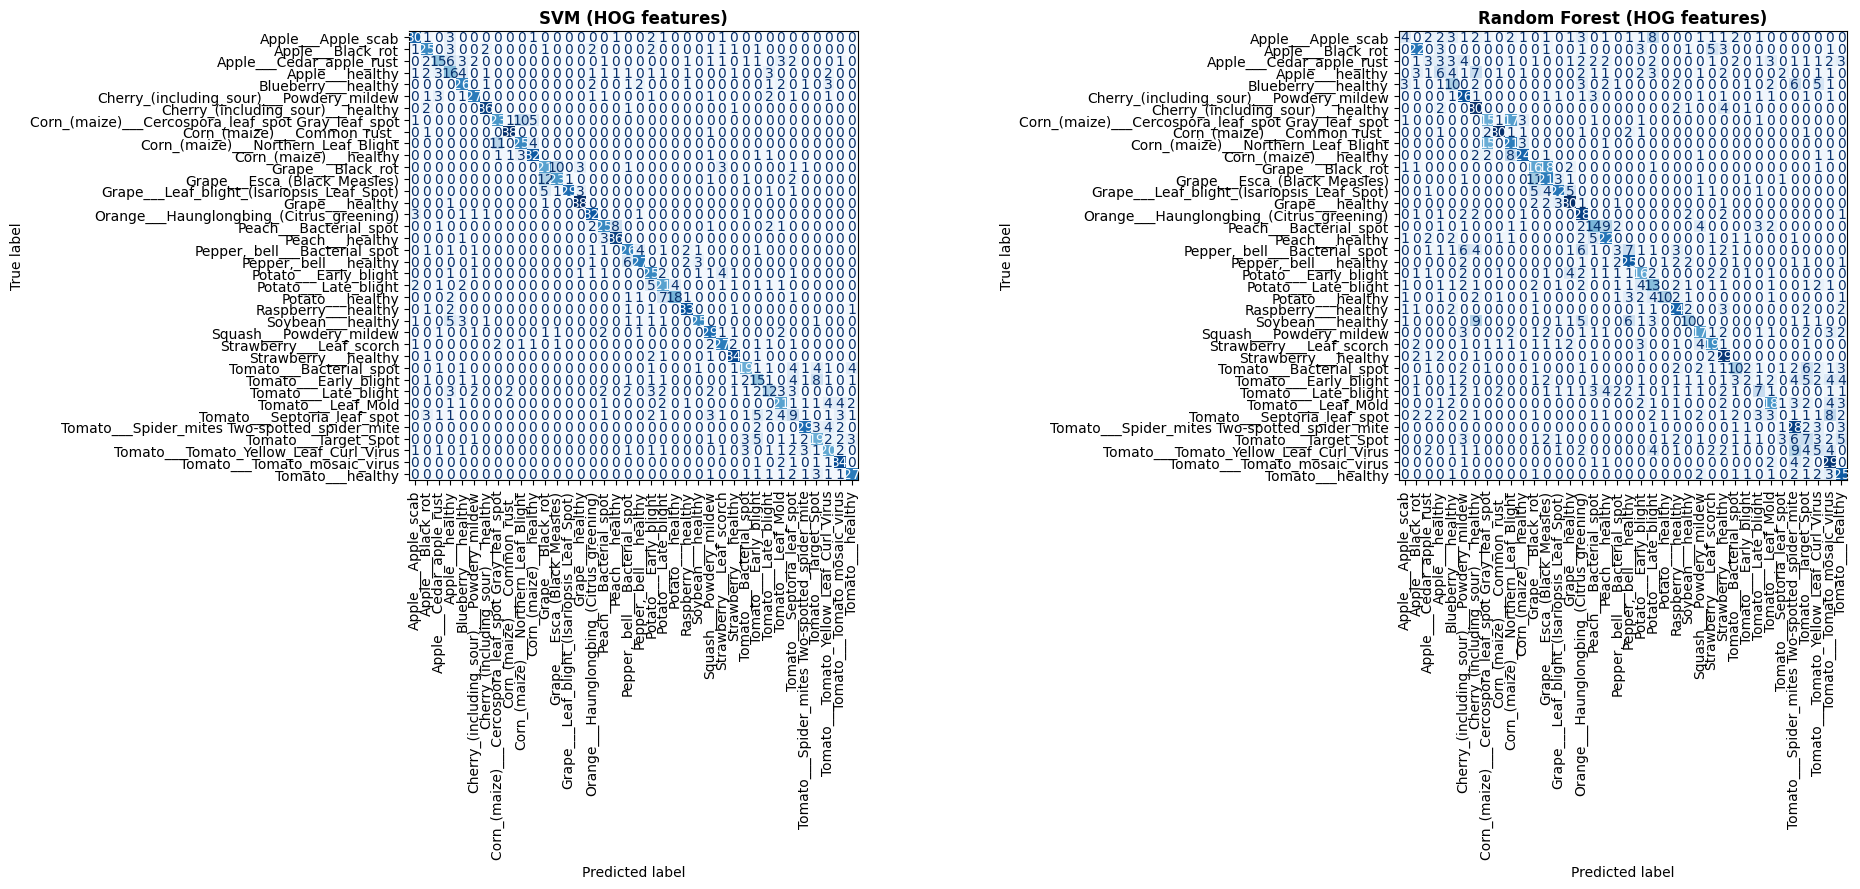

 Saved -> cm_classical.png


In [23]:
# Confusion Matrix Comparison (Classical Models) 
# This section compares the performance of two classical ML models:
# - SVM using HOG + PCA features
# - Random Forest using HOG + PCA features

# The confusion matrix helps visualize:
# - Which classes are correctly predicted
# - Which classes are being confused with each other

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Loop through both models and plot confusion matrices side by side
for ax, preds, title in zip(
    axes,
    [svm_preds, rf_preds],
    ["SVM (HOG features)", "Random Forest (HOG features)"]
):
    cm = confusion_matrix(y_te, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=90,
              cmap="Blues", values_format="d")
    ax.set_title(title, fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("cm_classical.png", dpi=150)
plt.show()
print(" Saved -> cm_classical.png")


         MODEL COMPARISON SUMMARY
              Model          Type  Accuracy
EfficientNetB0 (DL) Deep Learning  0.983962
          SVM (HOG)     Classical  0.639974
Random Forest (HOG)     Classical  0.424222


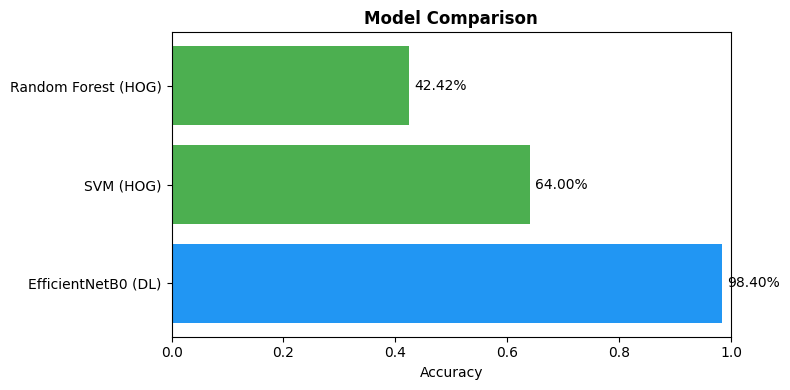

 Saved -> model_comparison.png


In [24]:
# This section compares all trained models in terms of accuracy:
# - EfficientNetB0 (Deep Learning model)
# - SVM (Classical ML with HOG features)
# - Random Forest (Classical ML with HOG features)
summary = pd.DataFrame({
    "Model":    ["EfficientNetB0 (DL)", "SVM (HOG)", "Random Forest (HOG)"],
    "Type":     ["Deep Learning",        "Classical", "Classical"],
    "Accuracy": [dl_accuracy, svm_accuracy, rf_accuracy]
}).sort_values("Accuracy", ascending=False)

print("\n" + "="*45)
print("         MODEL COMPARISON SUMMARY")
print("="*45)
print(summary.to_string(index=False))
print("="*45)

fig, ax = plt.subplots(figsize=(8, 4))
# Color coding:
# - Blue for Deep Learning
# - Green for Classical ML
colors = ["#2196F3" if t == "Deep Learning" else "#4CAF50"
          for t in summary["Type"]]
bars = ax.barh(summary["Model"], summary["Accuracy"], color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Model Comparison", fontweight="bold")
for bar, acc in zip(bars, summary["Accuracy"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{acc:.2%}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print(" Saved -> model_comparison.png")

In [25]:
# List everything that was saved 
saved_files = [
    "best_model.keras",
    "class_names.pkl",
    "dl_accuracy.pkl",
    "svm_model.pkl",
    "svm_accuracy.pkl",
    "rf_model.pkl",
    "rf_accuracy.pkl",
    "label_encoder.pkl",
    "hog_scaler.pkl",
    "hog_pca.pkl"
]

print(" Files to download for Streamlit app:\n")
for f in saved_files:
    exists = "FOUND" if os.path.exists(f) else "MISSING"
    print(f"   {exists}  {f}")

 Files to download for Streamlit app:

   FOUND  best_model.keras
   FOUND  class_names.pkl
   FOUND  dl_accuracy.pkl
   FOUND  svm_model.pkl
   FOUND  svm_accuracy.pkl
   FOUND  rf_model.pkl
   FOUND  rf_accuracy.pkl
   FOUND  label_encoder.pkl
   FOUND  hog_scaler.pkl
   FOUND  hog_pca.pkl


In [26]:
import os
files = ["best_model.keras", "class_names.pkl", "dl_accuracy.pkl",
         "svm_model.pkl", "svm_accuracy.pkl", "rf_model.pkl", 
         "rf_accuracy.pkl", "label_encoder.pkl", "hog_scaler.pkl", "hog_pca.pkl"]

for f in files:
    status = "FOUND" if os.path.exists(f) else "MISSING"
    print(f"{status} {f}")

FOUND best_model.keras
FOUND class_names.pkl
FOUND dl_accuracy.pkl
FOUND svm_model.pkl
FOUND svm_accuracy.pkl
FOUND rf_model.pkl
FOUND rf_accuracy.pkl
FOUND label_encoder.pkl
FOUND hog_scaler.pkl
FOUND hog_pca.pkl


In [27]:
import shutil
import os

# Saving 3 sample images per class from validation set for testing
save_dir = "test_samples"
os.makedirs(save_dir, exist_ok=True)

for cls in classes[:5]:  # grab from first 5 classes
    folder = os.path.join(IMAGE_ROOT, cls)
    images = os.listdir(folder)[-3:]  # last 3 images
    cls_dir = os.path.join(save_dir, cls)
    os.makedirs(cls_dir, exist_ok=True)
    for img in images:
        shutil.copy(os.path.join(folder, img), cls_dir)

print(" Test samples saved")

 Test samples saved
